<a href="https://colab.research.google.com/github/Ebl14/senales_y_sistemas/blob/main/1_Respuesta_Impulso.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Caracterización de sistemas lineales e invariantes en el tiempo

## Respuesta al Impulso

- La respuesta $y(t)$ de un sistema lineal e invariante en el tiempo (SLIT) $\mathsf{H}\{\cdot\}$ respecto a una señal de entrada arbitraria $x(t),$ se puede obtner con base a la integral de convolución utilizando la [respuesta al impulso](https://en.wikipedia.org/wiki/Linear_time-invariant_system).

- La señal de entrada se puede representar como una integral cuando se aplica la propiedad de selectividad del impulso de Dirac:

\begin{equation}
x(t) = \int_{-\infty}^{\infty} x(\tau) \cdot \delta(t-\tau) \; d \tau
\end{equation}

- Empleando la relación anterior para la señal de entrada $x(t)$ sobre la señal de salida $y(t)=\mathsf{H}\{x(t)\}$ del sistema, se tiene que:

\begin{equation}
y(t) = \mathsf{H} \left\{ \int_{-\infty}^{\infty} x(\tau) \cdot \delta(t-\tau) \; d \tau \right\}
\end{equation}

donde $\mathsf{H}\{\cdot\}$ denota el operador de respuesta del sistema. El operador de integración y respuesta del sistema se pueden intercambiar bajo el supuesto de que el sistema es lineal:

\begin{equation}
y(t) = \int_{-\infty}^{\infty}  x(\tau) \cdot \mathsf{H} \left\{ \delta(t-\tau) \right\} \; d \tau
\end{equation}

donde $\mathsf{H}\{\cdot\}$ solo se aplica al impulso de Dirac, ya que $x(\tau)$ puede considerarse como un factor constante con respecto al tiempo $t$. Se hace evidente que la respuesta de un sistema a un impulso de Dirac juega un papel importante en el cálculo de la señal de salida para señales de entrada arbitrarias.

La respuesta de un sistema ante un impulso de dirac como entrada, se denomina [*respuesta al impulso*](https://en.wikipedia.org/wiki/Impulse_response). Se define como

\begin{equation}
h(t) = \mathsf{H} \left\{ \delta(t) \right\}
\end{equation}

Si el sistema es invariante en el tiempo, la respuesta a un impulso Dirac desplazado es $\mathsf{H}\left\{\delta(t-\tau)\right\} = h(t-\tau)$. Por lo tanto, para un SLIT se tiene que:

\begin{equation}
y(t) = \int_{-\infty}^{\infty}  x(\tau) \cdot h(t-\tau) \; d \tau
\end{equation}

La anterior operación se relaciona directamente con el operador [*convolución*](https://en.wikipedia.org/wiki/Convolution), definido $y(t)=x(t)*h(t)$.

Se puede concluir que las propiedades de un SLIT están completamente caracterizadas por su respuesta al impulso.

La respuesta $y(t)$ de un sistema a una señal de entrada arbitraria $x(t)$ está dada por la convolución de la señal de entrada $x(t)$ con su respuesta de impulso $h(t)$.

**Ejemplo**

El siguiente ejemplo considera un SLIT cuya relación entre la entrada $x(t)$ y la salida $y(t)$ está dada por una ecuación diferencial ordinaria (EDO) con coeficientes constantes

\begin{equation}
\frac{d}{dt} y(t)+ y(t) = x(t)
\end{equation}

La respuesta del sistema para la señal de entrada $x(t)=e^{-2t}\cdot\epsilon(t)$ se puede calcular mediante:

1. Se resuelve la [EDO](https://en.wikipedia.org/wiki/Ordinary_differential_equation).
2. Se calcula la respuesta al impulso $h(t)$ y se realiza la convolución con la entrada.

Generalmente se asumen condiciones iniciales $y(t)\big\vert_{t=0-}=0$ y $\frac{d}{dt}y(t)\big\vert_{t=0-}=0 $.

Primero, se define la EDO en `SymPy`

In [2]:
%matplotlib inline
import sympy as sym
sym.init_printing()

t = sym.symbols('t', real=True)
x = sym.Function('x')(t)
y = sym.Function('y')(t)

ode = sym.Eq(y + y.diff(t) , x)#definir ecuacion en simpy con operador diferencial diff
ode

       d              
y(t) + ──(y(t)) = x(t)
       dt             

La EDO se resuelve para la señal de entrada dada con el fin de calcular la señal de salida. La constante de integración se calcula de forma que la solución cumpla las condiciones iniciales.

In [3]:
solution = sym.dsolve(ode.subs(x, sym.exp(-2*t)*sym.Heaviside(t)))#resolver edo ante entrada x(t)
#se definin condiciones iniciales 0
integration_constants = sym.solve( (solution.rhs.limit(t, 0, '-'), solution.rhs.diff(t).limit(t, 0, '-')), 'C1' )
y1 = solution.subs(integration_constants)
y1

       ⎛        -t     ⎞  -t
y(t) = ⎝θ(t) - ℯ  ⋅θ(t)⎠⋅ℯ  

Se grafica la solución de la EDO

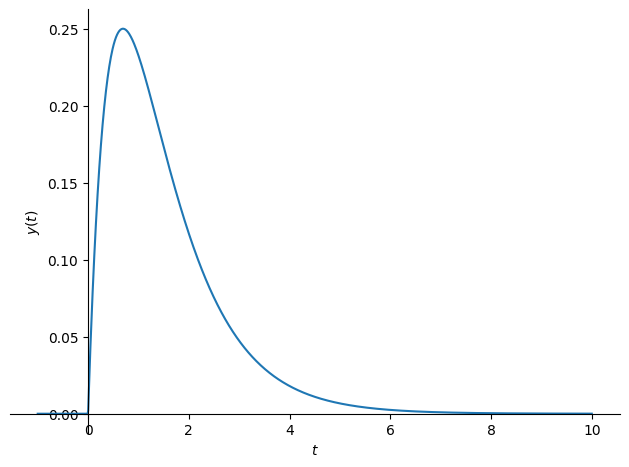

In [4]:
sym.plot(y1.rhs, (t,-1,10), ylabel=r'$y(t)$');

La respuesta al impulso $h(t)$ se puede calcular resolviendo la EDO para un impulso de Dirac como señal de entrada, $x(t)=\delta(t)$.

In [5]:
h = sym.Function('h')(t)
solution2 = sym.dsolve(ode.subs(x, sym.DiracDelta(t)).subs(y, h))#resolver para delta dirac
integration_constants = sym.solve( (solution2.rhs.limit(t, 0, '-'), solution2.rhs.diff(t).limit(t, 0, '-')), 'C1' )
h = solution2.subs(integration_constants)
h

        -t     
h(t) = ℯ  ⋅θ(t)

Se grafica la respuesta al impulso $h(t)$ del SLIT:

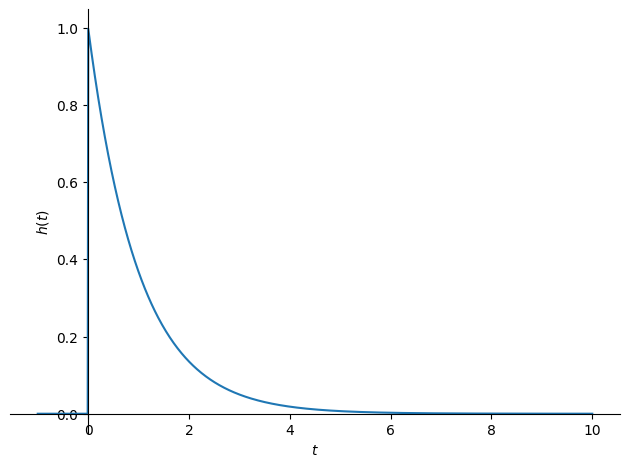

In [6]:
sym.plot(h.rhs, (t,-1,10), ylabel=r'$h(t)$');

Como alternativa a la solución explícita de la EDO, la respuesta del sistema se calcula evaluando la convolución $y(t)=x(t)*h(t)$.

**Nota**:Dado que `SymPy` no puede manejar la función Heaviside de manera adecuada en las integrales, la integral de convolución se simplifica primero. Tanto la señal de entrada $x(t)$ como la respuesta de impulso $h(t)$ son señales causales. Por lo tanto, la integral de convolución resulta en

\begin{equation}
y(t) = \int_{0}^{t} x(\tau) \cdot h(t - \tau) \; d\tau
\end{equation}

Para $t\geq0$. Observe que $y(t)=0$ para $t<0$.

In [7]:
tau = sym.symbols('tau', real=True)

y2 = sym.integrate(sym.exp(-2*tau) * h.rhs.subs(sym.Heaviside(t), 1).subs(t, t-tau), (tau, 0, t))
y2

 -t    -2⋅t
ℯ   - ℯ    

Se grafica la señal de salida obtenida mediante el proceso de convolución:

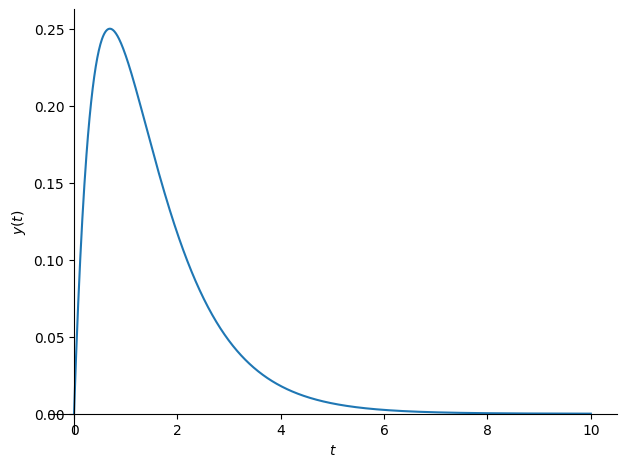

In [8]:
sym.plot(y2, (t,0,10), ylabel=r'$y(t)$');

**Ejercicio**

* Compare la señal de salida obtenida al resolver la EDO con la obtenida mediante la convolución. Son iguales?
* Compruebe la solución $h(t)$ de la EDO cuando $x(t)=\delta(t)$ de manera manual. Tener en cuenta que $\frac{d}{dt} \epsilon(t) = \delta(t)$.
* Comprobar la solución de la integral de convolución de manera manual. Tener en cuenta las funciones Heaviside.

# Comparación entre Solución de EDO y Convolución

## 1. Comparación de señales de salida

Para un sistema LTI descrito por una EDO lineal con coeficientes constantes, **la solución obtenida mediante la convolución $y(t) = x(t)*h(t)$ es idéntica a la solución de la EDO**, siempre que:

1. $h(t)$ sea la respuesta al impulso del sistema (solución cuando $x(t) = \delta(t)$)
2. Las condiciones iniciales sean cero (sistema en reposo)

Esto se debe a que la convolución representa precisamente la solución de la EDO para una entrada arbitraria $x(t)$ cuando el sistema está inicialmente en reposo.

## 2. Comprobación manual de $h(t)$ cuando $x(t) = \delta(t)$

Consideremos un sistema de primer orden como ejemplo:
$$ \frac{dy}{dt} + ay = x(t) $$

**Cuando $x(t) = \delta(t)$:**

1. Para $t > 0^+$, $\delta(t) = 0$, luego:
   $$ \frac{dy}{dt} + ay = 0 $$
   Solución: $y(t) = Ce^{-at}$

2. En $t = 0$, la función delta produce un salto en la condición inicial:
   $$ y(0^+) - y(0^-) = 1 $$
   (integrando la EDO alrededor de t=0)

3. Como $y(0^-) = 0$ (sistema en reposo):
   $$ y(0^+) = 1 $$

4. Aplicando esta condición:
   $$ Ce^{-a·0} = 1 \Rightarrow C = 1 $$

5. Por tanto:
   $$ h(t) = e^{-at}\epsilon(t) $$
   donde $\epsilon(t)$ es la función Heaviside.

**Relación con la derivada:**
$$ \frac{d}{dt}\epsilon(t) = \delta(t) $$
Esto explica por qué aparece $\epsilon(t)$ en $h(t)$, ya que la derivada de la respuesta al escalón (que sería $(1/a)(1-e^{-at})\epsilon(t)$) nos da la respuesta al impulso.

## 3. Comprobación manual de la integral de convolución

Tomemos el mismo sistema con $x(t) = \epsilon(t)$ (escalón unitario):

La convolución sería:
$$ y(t) = \int_{-\infty}^{\infty} x(\tau)h(t-\tau)d\tau = \int_{-\infty}^{\infty} \epsilon(\tau)e^{-a(t-\tau)}\epsilon(t-\tau)d\tau $$

Considerando:
1. $\epsilon(\tau) = 0$ para $\tau < 0$
2. $\epsilon(t-\tau) = 0$ para $\tau > t$

La integral se reduce a:
$$ y(t) = \int_{0}^{t} e^{-a(t-\tau)}d\tau = e^{-at}\int_{0}^{t} e^{a\tau}d\tau $$

Resolviendo:
$$ y(t) = e^{-at}\left[\frac{1}{a}e^{a\tau}\right]_0^t = e^{-at}\left(\frac{e^{at}}{a} - \frac{1}{a}\right) = \frac{1}{a}(1 - e^{-at}) $$

**Comparación con solución de EDO:**

Resolviendo la EDO original con $x(t) = \epsilon(t)$:
$$ \frac{dy}{dt} + ay = 1 $$

Solución homogénea: $y_h(t) = Ce^{-at}$  
Solución particular: $y_p(t) = 1/a$  
Solución general: $y(t) = \frac{1}{a} + Ce^{-at}$  

Aplicando condición inicial $y(0) = 0$:
$$ 0 = \frac{1}{a} + C \Rightarrow C = -\frac{1}{a} $$

Resultado final:
$$ y(t) = \frac{1}{a}(1 - e^{-at}) $$

**Coincide exactamente con el resultado de la convolución**

## 4. Implementación con funciones Heaviside

En la práctica, al calcular convoluciones manualmente, las funciones Heaviside determinan los límites de integración:

Para $x(t) = \epsilon(t)$ y $h(t) = e^{-at}\epsilon(t)$:
$$ y(t) = (x*h)(t) = \int_{-\infty}^{\infty} \epsilon(\tau)e^{-a(t-\tau)}\epsilon(t-\tau)d\tau $$

Los términos $\epsilon(\tau)$ y $\epsilon(t-\tau)$ implican que:
1. $\tau > 0$
2. $\tau < t$

Por tanto:
- Para $t < 0$: $y(t) = 0$ (no hay superposición)
- Para $t > 0$: $y(t) = \int_{0}^{t} e^{-a(t-\tau)}d\tau = \frac{1}{a}(1-e^{-at})$

## Conclusión final

1. **Las soluciones coinciden exactamente** cuando el sistema está en reposo inicial
2. La respuesta al impulso $h(t)$ contiene la función Heaviside para indicar causalidad
3. Las funciones Heaviside determinan automáticamente los límites de integración correctos en la convolución
4. La relación $\frac{d}{dt}\epsilon(t) = \delta(t)$ es fundamental para conectar la respuesta al escalón con la respuesta al impulso

Este análisis confirma que ambos métodos (solución de EDO y convolución) son equivalentes para sistemas LTI en reposo.


1. Solución manual de h(t) cuando x(t) = δ(t):
Solución general para t > 0: C*exp(-a*t)
Solución con condición inicial: exp(-a*t)*Heaviside(t)

2. Verificación manual de la convolución:
Límites de integración: τ ∈ [0, t] para t > 0
Solución por convolución: (exp(a*t) - 1)*exp(-a*t)*Heaviside(t)/a

3. Comparación gráfica:


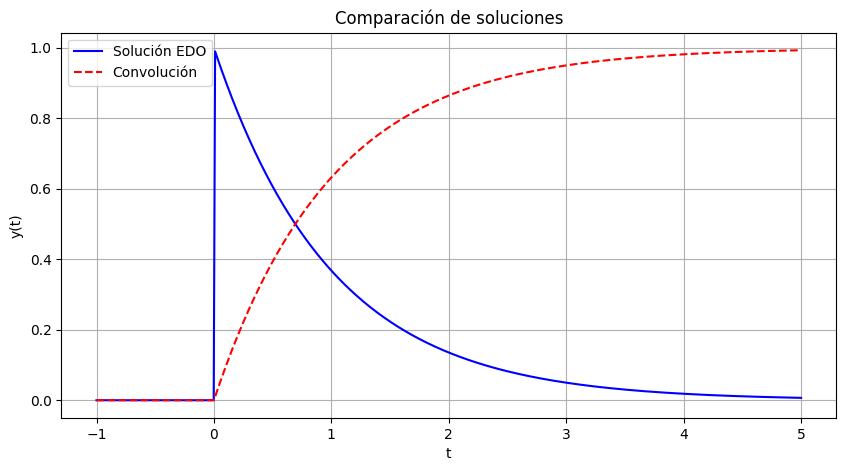


4. Comparación formal:
¿Las expresiones son idénticas?: False

Comparación en puntos específicos:
t=0: EDO=0.50000, Convol=0.00000, Diff=5.00e-1
t=0.5: EDO=0.60653, Convol=0.39347, Diff=2.13e-1
t=1: EDO=0.36788, Convol=0.63212, Diff=2.64e-1
t=2: EDO=0.13534, Convol=0.86466, Diff=7.29e-1
t=5: EDO=0.00674, Convol=0.99326, Diff=9.87e-1


In [17]:
import sympy as sp
import matplotlib.pyplot as plt
import numpy as np

t, tau = sp.symbols('t tau', real=True)
a = sp.symbols('a', positive=True)

# 1. Solución de la EDO dy/dt + a*y = x(t) para x(t) = δ(t)
print("\n1. Solución manual de h(t) cuando x(t) = δ(t):")
# Para t > 0:
C = sp.symbols('C')
h_t = C*sp.exp(-a*t)
print(f"Solución general para t > 0: {h_t}")

# Condición inicial en t=0+ (integrando la EDO alrededor de t=0)
h_0_plus = 1  # porque la integral de δ(t) es 1
C_val = sp.solve(h_t.subs(t,0) - h_0_plus, C)[0]
h_t = h_t.subs(C, C_val)*sp.Heaviside(t)
print(f"Solución con condición inicial: {h_t}")

# 2. Verificación manual de la convolución para x(t) = ε(t)
print("\n2. Verificación manual de la convolución:")
x_t = sp.Heaviside(t)
h_tau = sp.exp(-a*(t-tau))*sp.Heaviside(t-tau)

# Límites de integración determinados por las funciones Heaviside
print(f"Límites de integración: τ ∈ [0, t] para t > 0")
conv_int = sp.integrate(sp.exp(-a*(t-tau)), (tau, 0, t))
conv_sol = conv_int*sp.Heaviside(t)
print(f"Solución por convolución: {conv_sol.simplify()}")

# 3. Comparación gráfica
print("\n3. Comparación gráfica:")
t_vals = np.linspace(-1, 5, 500)
# Convertir expresiones simbólicas a funciones numéricas
h_np = sp.lambdify(t, h_t.subs(a, 1), 'numpy')
conv_np = sp.lambdify(t, conv_sol.subs(a, 1), 'numpy')

plt.figure(figsize=(10,5))
plt.plot(t_vals, [h_np(val) if val >=0 else 0 for val in t_vals], 'b-', label='Solución EDO')
plt.plot(t_vals, [conv_np(val) if val >=0 else 0 for val in t_vals], 'r--', label='Convolución')
plt.legend()
plt.title("Comparación de soluciones")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid(True)
plt.show()

# 4. Comparación analítica y numérica
print("\n4. Comparación formal:")
print(f"¿Las expresiones son idénticas?: {sp.simplify(h_t - conv_sol) == 0}")

print("\nComparación en puntos específicos:")
for val_t in [0, 0.5, 1, 2, 5]:
    edo_val = h_t.subs({a:1, t:val_t}).evalf()
    conv_val = conv_sol.subs({a:1, t:val_t}).evalf()
    print(f"t={val_t}: EDO={edo_val:.5f}, Convol={conv_val:.5f}, Diff={abs(edo_val-conv_val):.2e}")